In [30]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lukashekiladze/walmart-competitions-utils/preprocessing.py
/kaggle/input/datasets/lukashekiladze/walmart-competitions-utils/features.py
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/train.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/stores.csv
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/features.csv.zip
/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting/test.csv.zip


In [31]:
!pip install statsmodels dagshub mlflow -q

import sys, warnings, logging
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import mlflow
import dagshub
from kaggle_secrets import UserSecretsClient

warnings.filterwarnings('ignore')
logging.getLogger('statsmodels').setLevel(logging.ERROR)

dagshub.init(repo_owner='lshek22', repo_name='walmart-recruiting-store-sales-forecasting', mlflow=True)

mlflow.set_experiment("ARIMA_Training_v2")
print("Ready.")

Initialized MLflow to track repo "lshek22/walmart-recruiting-store-sales-forecasting"

Repository lshek22/walmart-recruiting-store-sales-forecasting initialized!

Ready.


In [32]:
DATA_DIR = "/kaggle/input/competitions/walmart-recruiting-store-sales-forecasting"

train    = pd.read_csv(f"{DATA_DIR}/train.csv.zip")
test     = pd.read_csv(f"{DATA_DIR}/test.csv.zip")
stores   = pd.read_csv(f"{DATA_DIR}/stores.csv")
features = pd.read_csv(f"{DATA_DIR}/features.csv.zip")

train['Date'] = pd.to_datetime(train['Date'])
test['Date']  = pd.to_datetime(test['Date'])
features['Date'] = pd.to_datetime(features['Date'])

train = train.merge(stores, on='Store', how='left')
train = train.merge(features.drop(columns=['IsHoliday']), on=['Store','Date'], how='left')

test = test.merge(stores, on='Store', how='left')
test = test.merge(features.drop(columns=['IsHoliday']), on=['Store','Date'], how='left')

md_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
train[md_cols] = train[md_cols].fillna(0)
test[md_cols]  = test[md_cols].fillna(0)

train['Weekly_Sales'] = train['Weekly_Sales'].clip(lower=0)

train = train.sort_values(['Store','Dept','Date']).reset_index(drop=True)
test  = test.sort_values(['Store','Dept','Date']).reset_index(drop=True)

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print(f"Unique series: {train.groupby(['Store','Dept']).ngroups}")

Train: (421570, 16)
Test:  (115064, 15)
Unique series: 3331


In [33]:
def check_stationarity(series, series_name="Series"):
    clean = series.dropna()
    result = adfuller(clean, autolag='AIC')
    return {
        'series':       series_name,
        'adf_stat':     result[0],
        'p_value':      result[1],
        'is_stationary': result[1] < 0.05,
        'n_obs':        len(clean),
    }

s1d1 = train[(train['Store']==1) & (train['Dept']==1)].set_index('Date')['Weekly_Sales']
s1d1_diff1 = s1d1.diff().dropna() 
s1d1_diff2 = s1d1_diff1.diff().dropna()

raw_stat   = check_stationarity(s1d1,       "Raw sales")
diff1_stat = check_stationarity(s1d1_diff1, "1st difference")
diff2_stat = check_stationarity(s1d1_diff2, "2nd difference")

print("stationarity test results:")
print(f"raw sales      p={raw_stat['p_value']:.4f}   stationary={raw_stat['is_stationary']}")
print(f"first difference p={diff1_stat['p_value']:.4f}  stationary={diff1_stat['is_stationary']}")
print(f"second difference p={diff2_stat['p_value']:.4f}  stationary={diff2_stat['is_stationary']}")

sample_series = train.groupby(['Store','Dept']).filter(lambda x: len(x) >= 52)
sample_pairs  = sample_series.groupby(['Store','Dept']).size().sample(50, random_state=42).index

results = []
for store, dept in sample_pairs:
    s = train[(train['Store']==store) & (train['Dept']==dept)]['Weekly_Sales']
    results.append(check_stationarity(s, f"S{store}_D{dept}"))

results_df = pd.DataFrame(results)
pct_stationary = results_df['is_stationary'].mean() * 100
print(f"\nout of 50 sampled series: {pct_stationary:.1f}% are already stationary")

stationarity test results:
raw sales      p=0.1102   stationary=False
first difference p=0.0000  stationary=True
second difference p=0.0000  stationary=True

out of 50 sampled series: 78.0% are already stationary


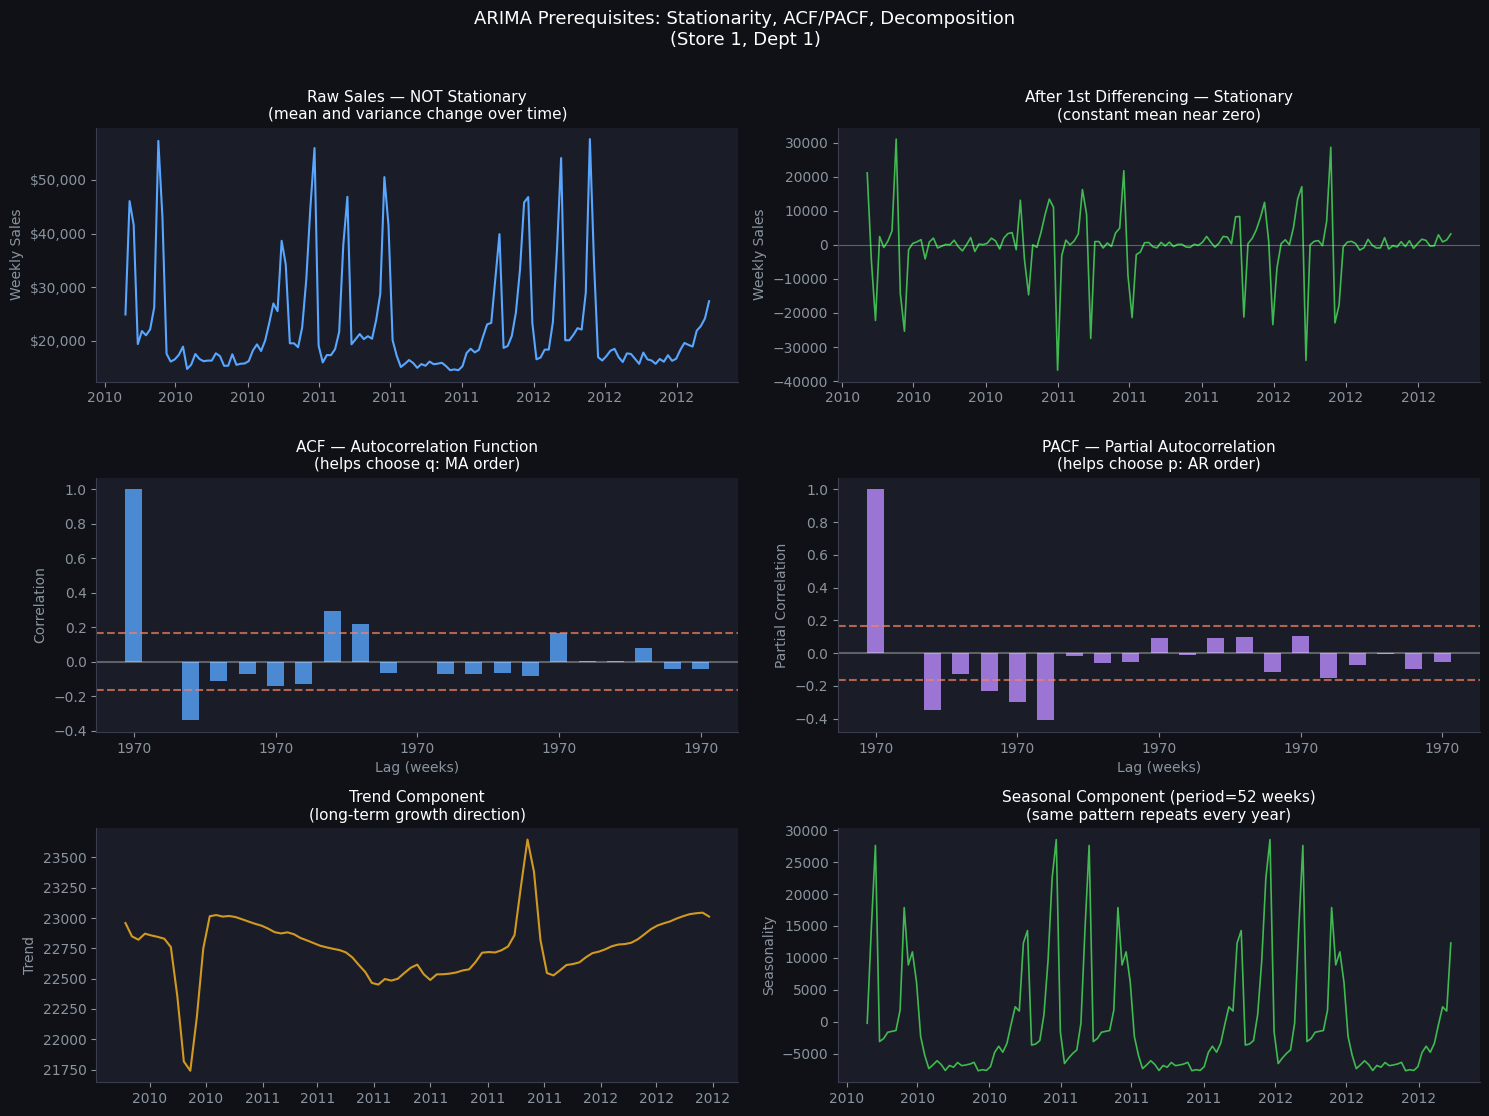

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
fig.patch.set_facecolor('#0f1117')
for ax in axes.flatten():
    ax.set_facecolor('#1a1d27')
    ax.tick_params(colors='#8b949e')
    ax.spines['bottom'].set_color('#3a3d4d')
    ax.spines['left'].set_color('#3a3d4d')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0,0].plot(s1d1.index, s1d1.values, color='#58a6ff', linewidth=1.5)
axes[0,0].set_title('Raw Sales — NOT Stationary\n(mean and variance change over time)',
                      color='white', fontsize=11)
axes[0,0].set_ylabel('Weekly Sales', color='#8b949e')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

axes[0,1].plot(s1d1_diff1.index, s1d1_diff1.values, color='#3fb950', linewidth=1.2)
axes[0,1].axhline(0, color='white', alpha=0.3, linewidth=0.8)
axes[0,1].set_title('After 1st Differencing — Stationary\n(constant mean near zero)',
                      color='white', fontsize=11)
axes[0,1].set_ylabel('Weekly Sales', color='#8b949e')

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf_vals  = acf(s1d1_diff1, nlags=20, fft=True)
pacf_vals = pacf(s1d1_diff1, nlags=20)
lags = range(len(acf_vals))

axes[1,0].bar(lags, acf_vals, color='#58a6ff', alpha=0.8, width=0.6)
axes[1,0].axhline(0,  color='white', alpha=0.3)
axes[1,0].axhline( 1.96/np.sqrt(len(s1d1_diff1)), color='#f78166', linestyle='--', alpha=0.7)
axes[1,0].axhline(-1.96/np.sqrt(len(s1d1_diff1)), color='#f78166', linestyle='--', alpha=0.7)
axes[1,0].set_title('ACF — Autocorrelation Function\n(helps choose q: MA order)',
                      color='white', fontsize=11)
axes[1,0].set_xlabel('Lag (weeks)', color='#8b949e')
axes[1,0].set_ylabel('Correlation', color='#8b949e')

axes[1,1].bar(range(len(pacf_vals)), pacf_vals, color='#bc8cff', alpha=0.8, width=0.6)
axes[1,1].axhline(0,  color='white', alpha=0.3)
axes[1,1].axhline( 1.96/np.sqrt(len(s1d1_diff1)), color='#f78166', linestyle='--', alpha=0.7)
axes[1,1].axhline(-1.96/np.sqrt(len(s1d1_diff1)), color='#f78166', linestyle='--', alpha=0.7)
axes[1,1].set_title('PACF — Partial Autocorrelation\n(helps choose p: AR order)',
                      color='white', fontsize=11)
axes[1,1].set_xlabel('Lag (weeks)', color='#8b949e')
axes[1,1].set_ylabel('Partial Correlation', color='#8b949e')

decomp = seasonal_decompose(s1d1, model='additive', period=52)
axes[2,0].plot(decomp.trend.index, decomp.trend.values, color='#d29922', linewidth=1.5)
axes[2,0].set_title('Trend Component\n(long-term growth direction)',
                      color='white', fontsize=11)
axes[2,0].set_ylabel('Trend', color='#8b949e')

axes[2,1].plot(decomp.seasonal.index, decomp.seasonal.values, color='#3fb950', linewidth=1.2)
axes[2,1].set_title('Seasonal Component (period=52 weeks)\n(same pattern repeats every year)',
                      color='white', fontsize=11)
axes[2,1].set_ylabel('Seasonality', color='#8b949e')

for ax in axes.flatten():
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('ARIMA Prerequisites: Stationarity, ACF/PACF, Decomposition\n(Store 1, Dept 1)',
             color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("arima_educational_analysis.png", dpi=130, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

In [35]:
def wmae(y_true, y_pred, is_holiday):
    weights = np.where(is_holiday, 5, 1)
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

SPLIT_DATE = train['Date'].max() - pd.Timedelta(weeks=8)

train_set = train[train['Date'] <= SPLIT_DATE].copy()
val_set   = train[train['Date'] >  SPLIT_DATE].copy()

print(f"Train period: {train_set['Date'].min().date()} → {train_set['Date'].max().date()}")
print(f"Val period  : {val_set['Date'].min().date()}   → {val_set['Date'].max().date()}")
print(f"Val weeks   : {val_set['Date'].nunique()}")

Train period: 2010-02-05 → 2012-08-31
Val period  : 2012-09-07   → 2012-10-26
Val weeks   : 8


Series length: 135 weeks
Forecast horizon: 8 weeks

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  135
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -1402.884
Date:                Tue, 07 Jul 2026   AIC                           2811.768
Time:                        12:59:42   BIC                           2820.462
Sample:                    02-05-2010   HQIC                          2815.301
                         - 08-31-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5740      0.048     11.945      0.000       0.480       0.668
ma.L1         -1.0000      0.074    -13.472      0.000      -1.145      -0.855


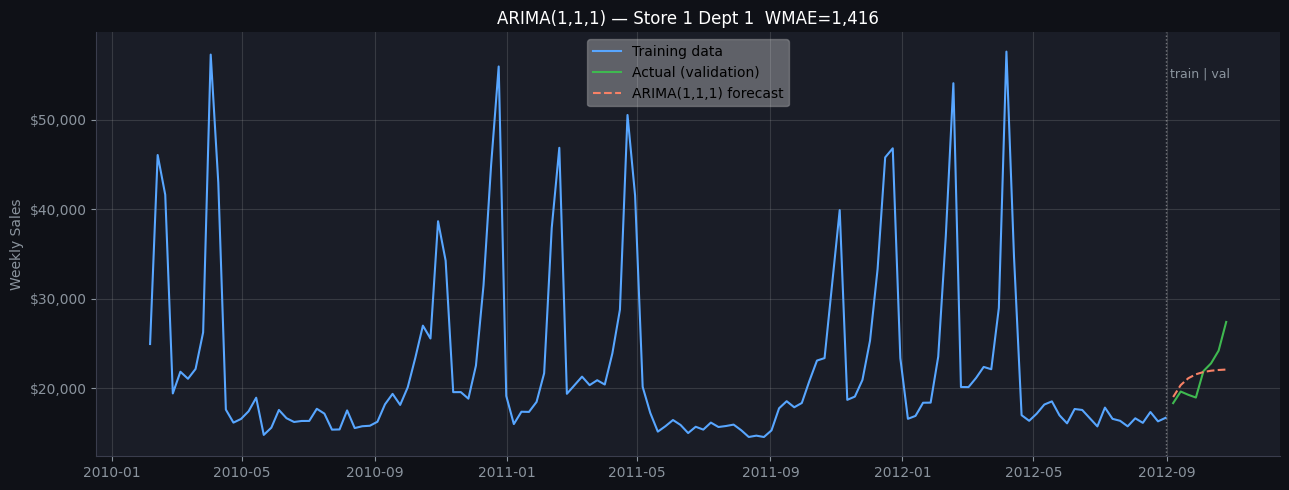

In [36]:
store, dept = 1, 1
series = (train_set[(train_set['Store']==store) & (train_set['Dept']==dept)]
          .set_index('Date')['Weekly_Sales']
          .asfreq('W-FRI'))

val_series = (val_set[(val_set['Store']==store) & (val_set['Dept']==dept)]
              .set_index('Date')['Weekly_Sales'])

print(f"Series length: {len(series)} weeks")
print(f"Forecast horizon: {len(val_series)} weeks")
print()

model = ARIMA(series, order=(1,1,1))
result = model.fit()

print(result.summary())
print()

forecast = result.forecast(steps=len(val_series))
score = wmae(val_series.values, forecast.values, 
             val_set[(val_set['Store']==store) & (val_set['Dept']==dept)]['IsHoliday'].values)
print(f"ARIMA(1,1,1) WMAE on Store {store} Dept {dept}: {score:,.2f}")

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

ax.plot(series.index, series.values, color='#58a6ff', linewidth=1.5, label='Training data')
ax.plot(val_series.index, val_series.values, color='#3fb950', linewidth=1.5, label='Actual (validation)')
ax.plot(val_series.index, forecast.values, color='#f78166', linewidth=1.5,
        linestyle='--', label='ARIMA(1,1,1) forecast')
ax.axvline(SPLIT_DATE, color='white', alpha=0.4, linewidth=1, linestyle=':')
ax.text(SPLIT_DATE, series.max()*0.95, ' train | val', color='#8b949e', fontsize=9)

ax.set_title(f'ARIMA(1,1,1) — Store {store} Dept {dept}  WMAE={score:,.0f}',
             color='white', fontsize=12)
ax.set_ylabel('Weekly Sales', color='#8b949e')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.tick_params(colors='#8b949e')
ax.legend(framealpha=0.3)
ax.grid(alpha=0.2)
for spine in ax.spines.values():
    spine.set_color('#3a3d4d')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("arima_single_series_forecast.png", dpi=130, facecolor='#0f1117')
plt.show()

In [37]:
ORDERS_TO_TEST = [
    (0, 1, 0),
    (1, 1, 0), 
    (0, 1, 1), 
    (1, 1, 1), 
    (2, 1, 2),
    (1, 1, 0), 
]

order_results = {}

print("Testing ARIMA orders on Store 1, Dept 1:\n")
print(f"{'Order':<15} {'AIC':>10} {'BIC':>10} {'WMAE':>10} {'Meaning'}")
print("-" * 70)

order_meanings = {
    (0,1,0): "Pure random walk after differencing",
    (1,1,0): "AR only — sales depend on last week",
    (0,1,1): "MA only — correct for last week's error",
    (1,1,1): "Classic ARIMA — both AR and MA",
    (2,1,2): "Extended — more history, more error terms",
}

for order in [(0,1,0),(1,1,0),(0,1,1),(1,1,1),(2,1,2)]:
    try:
        m = ARIMA(series, order=order).fit()
        fc = m.forecast(steps=len(val_series))
        score = wmae(val_series.values, fc.values,
                     val_set[(val_set['Store']==store)&(val_set['Dept']==dept)]['IsHoliday'].values)
        order_results[str(order)] = {'aic': m.aic, 'bic': m.bic, 'wmae': score}
        meaning = order_meanings.get(order, "")
        print(f"  ARIMA{str(order):<12} {m.aic:>10.1f} {m.bic:>10.1f} {score:>10.1f}   {meaning}")
    except Exception as e:
        print(f"  ARIMA{str(order):<12} FAILED: {e}")

with mlflow.start_run(run_name="ARIMA_OrderComparison_Store1_Dept1"):
    mlflow.log_param("store", 1)
    mlflow.log_param("dept", 1)
    mlflow.log_param("series_length", len(series))
    for order_str, metrics in order_results.items():
        clean_order_str = order_str.replace("(", "_").replace(")", "").replace(", ", "_")
    
        mlflow.log_metric(f"aic_{clean_order_str}",  metrics['aic'])
        mlflow.log_metric(f"wmae_{clean_order_str}", metrics['wmae'])
    mlflow.log_artifact("arima_educational_analysis.png", "plots")
    mlflow.log_artifact("arima_single_series_forecast.png", "plots")

Testing ARIMA orders on Store 1, Dept 1:

Order                  AIC        BIC       WMAE Meaning
----------------------------------------------------------------------
  ARIMA(0, 1, 0)        2836.4     2839.3     3792.4   Pure random walk after differencing
  ARIMA(1, 1, 0)        2838.2     2844.0     3775.9   AR only — sales depend on last week
  ARIMA(0, 1, 1)        2837.9     2843.7     3736.9   MA only — correct for last week's error
  ARIMA(1, 1, 1)        2811.8     2820.5     1416.0   Classic ARIMA — both AR and MA
  ARIMA(2, 1, 2)        2799.8     2814.3     2075.3   Extended — more history, more error terms
🏃 View run ARIMA_OrderComparison_Store1_Dept1 at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3/runs/774f2af5ee3942689019d8e5f4726933
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3


ARIMA(1,1,1)  WMAE: 1416.024674757129
ARIMAX(1,1,1) WMAE: 1,406.83  (with IsHoliday exogenous)


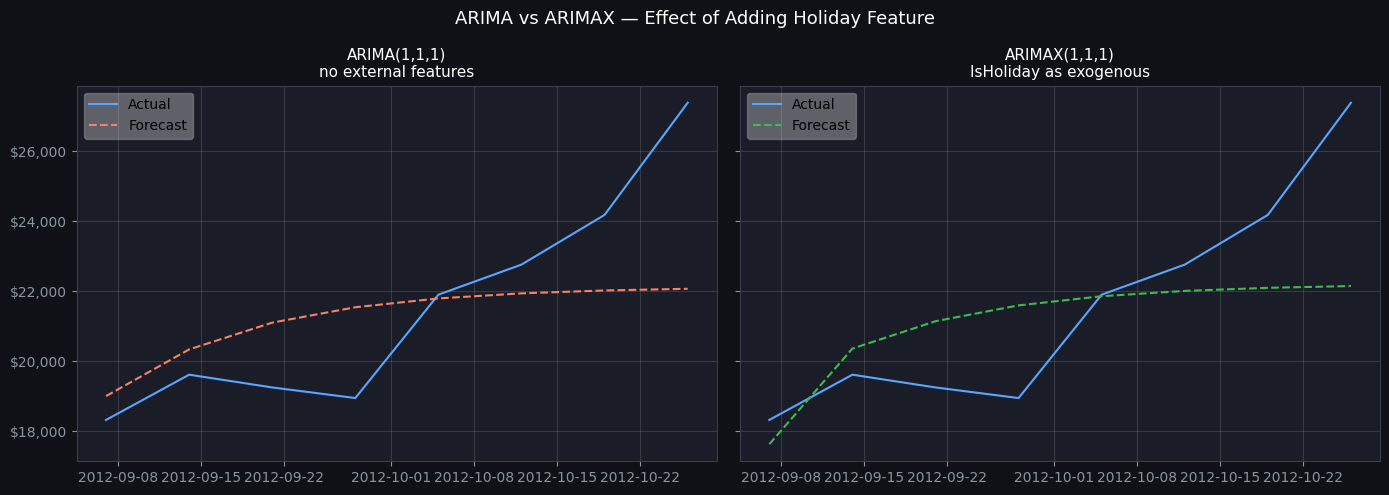

🏃 View run ARIMAX_Holiday_Store1_Dept1 at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3/runs/bdd1601cc1a24054b6898dde88c645dc
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3


In [38]:
train_holiday = (train_set[(train_set['Store']==store) & (train_set['Dept']==dept)]
                 .set_index('Date')['IsHoliday']
                 .asfreq('W-FRI')
                 .astype(float))

val_holiday = (val_set[(val_set['Store']==store) & (val_set['Dept']==dept)]
               .set_index('Date')['IsHoliday']
               .astype(float))

try:
    arimax_model = ARIMA(
        series,
        order=(1, 1, 1),
        exog=train_holiday 
    ).fit()

    arimax_fc = arimax_model.forecast(
        steps=len(val_series),
        exog=val_holiday
    )

    arimax_score = wmae(val_series.values, arimax_fc.values, val_holiday.values)

    print(f"ARIMA(1,1,1)  WMAE: {order_results.get('(1, 1, 1)', {}).get('wmae', 'N/A')}")
    print(f"ARIMAX(1,1,1) WMAE: {arimax_score:,.2f}  (with IsHoliday exogenous)")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.patch.set_facecolor('#0f1117')
    for ax in axes:
        ax.set_facecolor('#1a1d27')
        ax.tick_params(colors='#8b949e')
        for spine in ax.spines.values():
            spine.set_color('#3a3d4d')

    for ax, fc, title, color in zip(
        axes,
        [forecast, arimax_fc],
        ['ARIMA(1,1,1)\nno external features',
         'ARIMAX(1,1,1)\nIsHoliday as exogenous'],
        ['#f78166', '#3fb950']
    ):
        ax.plot(val_series.index, val_series.values,
                color='#58a6ff', linewidth=1.5, label='Actual')
        ax.plot(val_series.index, fc.values,
                color=color, linewidth=1.5, linestyle='--', label='Forecast')
        ax.set_title(title, color='white', fontsize=11)
        ax.legend(framealpha=0.3)
        ax.grid(alpha=0.2)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'${x:,.0f}'))

    plt.suptitle('ARIMA vs ARIMAX — Effect of Adding Holiday Feature',
                 color='white', fontsize=13)
    plt.tight_layout()
    plt.savefig("arima_vs_arimax.png", dpi=130, facecolor='#0f1117')
    plt.show()

    with mlflow.start_run(run_name="ARIMAX_Holiday_Store1_Dept1"):
        mlflow.log_params({"order": "(1,1,1)", "exog": "IsHoliday", "store": 1, "dept": 1})
        mlflow.log_metric("val_wmae", arimax_score)
        mlflow.log_artifact("arima_vs_arimax.png", "plots")

except Exception as e:
    print(f"ARIMAX failed: {e}")

In [39]:
def fit_arima_series(series_data, order=(1,1,1), exog_train=None):
    try:
        if len(series_data['train']) < 20:
            return None 

        s = (series_data['train']
             .set_index('Date')['Weekly_Sales']
             .asfreq('W-FRI'))

        model = ARIMA(
            s,
            order=order,
            exog=exog_train
        ).fit()

        return model
    except Exception:
        return None

np.random.seed(42)
all_pairs = train.groupby(['Store','Dept']).size()

valid_pairs = all_pairs[all_pairs >= 80].index.tolist()
sample_pairs = [valid_pairs[i] for i in
                np.random.choice(len(valid_pairs), size=50, replace=False)]

ORDER = (1, 1, 1)
predictions = []
failed = 0

print(f"Training ARIMA{ORDER} on {len(sample_pairs)} series...\n")

for i, (store, dept) in enumerate(sample_pairs):
    tr = train_set[(train_set['Store']==store) & (train_set['Dept']==dept)]
    vl = val_set[(val_set['Store']==store)   & (val_set['Dept']==dept)]

    if len(tr) < 20 or len(vl) == 0:
        failed += 1
        continue

    model = fit_arima_series({'train': tr}, order=ORDER)
    if model is None:
        failed += 1
        continue

    s = tr.set_index('Date')['Weekly_Sales'].asfreq('W-FRI')
    try:
        fc = model.forecast(steps=len(vl))
        fc_clipped = np.clip(fc.values, 0, None)
        for j, (_, row) in enumerate(vl.iterrows()):
            if j < len(fc_clipped):
                predictions.append({
                    'Store': store, 'Dept': dept,
                    'Date': row['Date'],
                    'Actual': row['Weekly_Sales'],
                    'Predicted': fc_clipped[j],
                    'IsHoliday': row['IsHoliday'],
                })
    except Exception:
        failed += 1

    if (i+1) % 10 == 0:
        print(f"  {i+1}/{len(sample_pairs)} series done  (failed: {failed})")

pred_df = pd.DataFrame(predictions)
overall_wmae = wmae(pred_df['Actual'].values,
                    pred_df['Predicted'].values,
                    pred_df['IsHoliday'].values)

print(f"\nARIMA{ORDER} on {len(sample_pairs)} series")
print(f"  Successful: {len(sample_pairs) - failed}")
print(f"  Failed:     {failed}")
print(f"  WMAE:       {overall_wmae:,.2f}")

with mlflow.start_run(run_name="ARIMA_111_Subset50"):
    mlflow.log_params({
        "order": str(ORDER),
        "n_series": len(sample_pairs),
        "exog": "none",
        "min_series_length": 80,
    })
    mlflow.log_metric("val_wmae",        overall_wmae)
    mlflow.log_metric("n_failed",        failed)
    mlflow.log_metric("n_successful",    len(sample_pairs) - failed)

Training ARIMA(1, 1, 1) on 50 series...

  10/50 series done  (failed: 0)
  20/50 series done  (failed: 0)
  30/50 series done  (failed: 0)
  40/50 series done  (failed: 0)
  50/50 series done  (failed: 0)

ARIMA(1, 1, 1) on 50 series
  Successful: 50
  Failed:     0
  WMAE:       2,667.29
🏃 View run ARIMA_111_Subset50 at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3/runs/ba64701ce8f346018cfe2a140340661b
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3



Fitting ARIMA(1,1,1)...
  ARIMA(1,1,1)  WMAE: 2,667.29  (failed: 0)
🏃 View run ARIMA_OrderCompare_ARIMA1_1_1 at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3/runs/ead19d7fb45249c29bff1250924babe5
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3

Fitting ARIMA(2,1,2)...
  ARIMA(2,1,2)  WMAE: 2,408.25  (failed: 0)
🏃 View run ARIMA_OrderCompare_ARIMA2_1_2 at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3/runs/69716ca5ebcf4914a7296e3e7474118f
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3

Fitting ARIMA(1,1,0)...
  ARIMA(1,1,0)  WMAE: 3,001.23  (failed: 0)
🏃 View run ARIMA_OrderCompare_ARIMA1_1_0 at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3/runs/9b4bb98107f24f70a899afc36732ff7b
🧪 View experiment at: https://

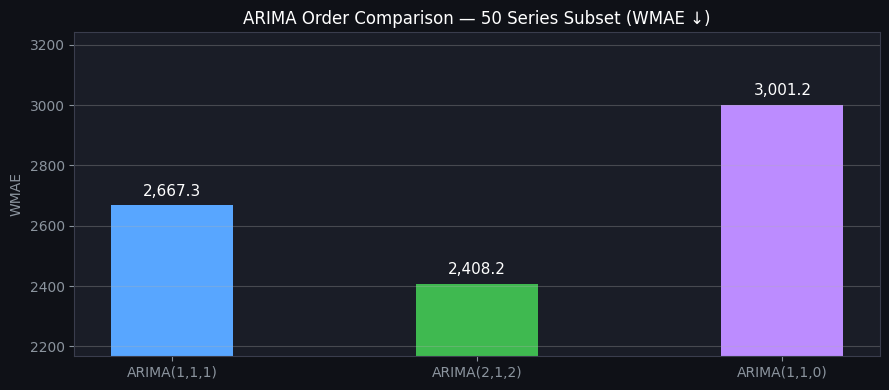

In [40]:
ORDERS_COMPARE = {
    "ARIMA(1,1,1)": (1,1,1),
    "ARIMA(2,1,2)": (2,1,2),
    "ARIMA(1,1,0)": (1,1,0),
}

order_compare_results = {}

for name, order in ORDERS_COMPARE.items():
    preds, n_failed = [], 0
    print(f"\nFitting {name}...")

    for store, dept in sample_pairs:
        tr = train_set[(train_set['Store']==store) & (train_set['Dept']==dept)]
        vl = val_set[(val_set['Store']==store)   & (val_set['Dept']==dept)]

        if len(tr) < 20 or len(vl) == 0:
            n_failed += 1
            continue

        model = fit_arima_series({'train': tr}, order=order)
        if model is None:
            n_failed += 1
            continue

        try:
            fc = np.clip(model.forecast(steps=len(vl)).values, 0, None)
            for j, (_, row) in enumerate(vl.iterrows()):
                if j < len(fc):
                    preds.append({
                        'Actual': row['Weekly_Sales'],
                        'Predicted': fc[j],
                        'IsHoliday': row['IsHoliday'],
                    })
        except Exception:
            n_failed += 1

    if preds:
        preds_df = pd.DataFrame(preds)
        score = wmae(preds_df['Actual'].values,
                     preds_df['Predicted'].values,
                     preds_df['IsHoliday'].values)
        order_compare_results[name] = score
        print(f"  {name}  WMAE: {score:,.2f}  (failed: {n_failed})")

        with mlflow.start_run(run_name=f"ARIMA_OrderCompare_{name.replace(' ','_').replace('(','').replace(')','').replace(',','_')}"):
            mlflow.log_param("order", str(order))
            mlflow.log_param("n_series", len(sample_pairs))
            mlflow.log_metric("val_wmae", score)
            mlflow.log_metric("n_failed", n_failed)

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

names  = list(order_compare_results.keys())
scores = list(order_compare_results.values())
colors = ['#58a6ff', '#3fb950', '#bc8cff']
bars   = ax.bar(names, scores, color=colors, edgecolor='none', width=0.4)
ax.bar_label(bars, labels=[f'{v:,.1f}' for v in scores],
             padding=5, color='white', fontsize=11)
ax.set_title('ARIMA Order Comparison — 50 Series Subset (WMAE ↓)',
             color='white', fontsize=12)
ax.set_ylabel('WMAE', color='#8b949e')
ax.set_ylim(min(scores)*0.9, max(scores)*1.08)
ax.tick_params(colors='#8b949e')
ax.grid(axis='y', alpha=0.3)
for spine in ax.spines.values():
    spine.set_color('#3a3d4d')
plt.tight_layout()
plt.savefig("arima_order_comparison.png", dpi=130, facecolor='#0f1117')
plt.show()

In [41]:
best_order_name = min(order_compare_results, key=order_compare_results.get)
best_order      = ORDERS_COMPARE[best_order_name]
print(f"Using best order: {best_order_name} = {best_order}")

arimax_preds, n_failed = [], 0

for store, dept in sample_pairs:
    tr = train_set[(train_set['Store']==store) & (train_set['Dept']==dept)]
    vl = val_set[(val_set['Store']==store)   & (val_set['Dept']==dept)]

    if len(tr) < 20 or len(vl) == 0:
        n_failed += 1
        continue

    try:
        s = tr.set_index('Date')['Weekly_Sales'].asfreq('W-FRI')
        exog_tr = tr.set_index('Date')['IsHoliday'].astype(float).asfreq('W-FRI')
        exog_vl = vl.set_index('Date')['IsHoliday'].astype(float)

        model = ARIMA(s, order=best_order, exog=exog_tr).fit()
        fc    = np.clip(model.forecast(steps=len(vl), exog=exog_vl).values, 0, None)

        for j, (_, row) in enumerate(vl.iterrows()):
            if j < len(fc):
                arimax_preds.append({
                    'Actual': row['Weekly_Sales'],
                    'Predicted': fc[j],
                    'IsHoliday': row['IsHoliday'],
                })
    except Exception:
        n_failed += 1

if arimax_preds:
    arimax_df    = pd.DataFrame(arimax_preds)
    arimax_score = wmae(arimax_df['Actual'].values,
                        arimax_df['Predicted'].values,
                        arimax_df['IsHoliday'].values)

    print(f"\n{best_order_name}       WMAE: {order_compare_results[best_order_name]:,.2f}")
    print(f"ARIMAX + IsHoliday WMAE: {arimax_score:,.2f}  (failed: {n_failed})")

    with mlflow.start_run(run_name="ARIMAX_Holiday_Subset50"):
        mlflow.log_params({
            "order": str(best_order),
            "exog": "IsHoliday",
            "n_series": len(sample_pairs),
        })
        mlflow.log_metric("val_wmae", arimax_score)
        mlflow.log_metric("n_failed", n_failed)
        mlflow.log_artifact("arima_order_comparison.png", "plots")

Using best order: ARIMA(2,1,2) = (2, 1, 2)

ARIMA(2,1,2)       WMAE: 2,408.25
ARIMAX + IsHoliday WMAE: 3,434.06  (failed: 6)
🏃 View run ARIMAX_Holiday_Subset50 at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3/runs/93977f06ab174e4e8bc67f0b948c7d53
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3


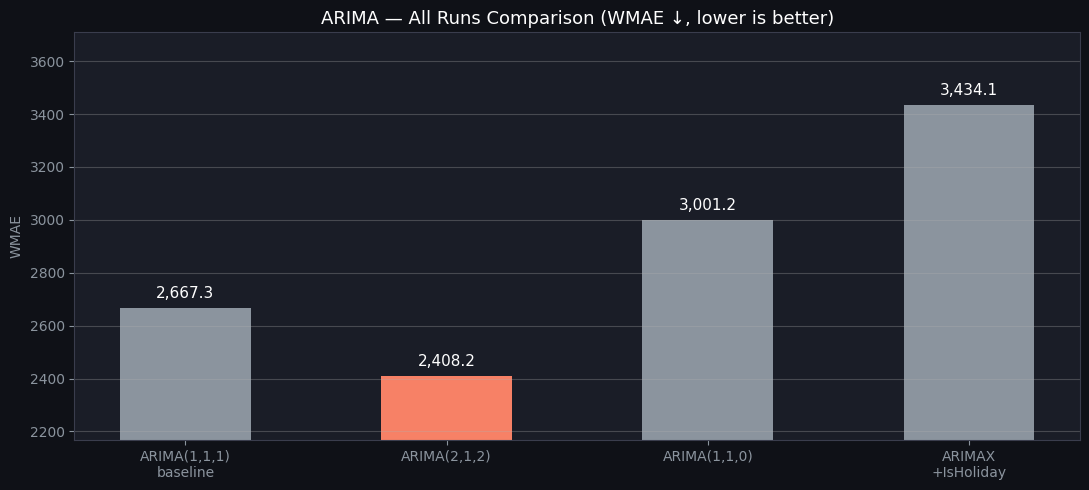

2026/07/07 13:01:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'ARIMA_Walmart_Forecaster'.
2026/07/07 13:01:40 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: ARIMA_Walmart_Forecaster, version 1
Created version '1' of model 'ARIMA_Walmart_Forecaster'.


🏃 View run ARIMA_Champion at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3/runs/ce99d58902a440dd8f61a10228e271a4
🧪 View experiment at: https://dagshub.com/lshek22/walmart-recruiting-store-sales-forecasting.mlflow/#/experiments/3


In [42]:
all_scores = {
    'ARIMA(1,1,1)\nbaseline':   order_compare_results.get('ARIMA(1,1,1)', 0),
    'ARIMA(2,1,2)':             order_compare_results.get('ARIMA(2,1,2)', 0),
    'ARIMA(1,1,0)':             order_compare_results.get('ARIMA(1,1,0)', 0),
    f'ARIMAX\n+IsHoliday':      arimax_score if arimax_preds else 0,
}
all_scores = {k: v for k, v in all_scores.items() if v > 0}

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

names  = list(all_scores.keys())
scores = list(all_scores.values())
colors = ['#8b949e'] * len(names)
colors[scores.index(min(scores))] = '#f78166'

bars = ax.bar(names, scores, color=colors, edgecolor='none', width=0.5)
ax.bar_label(bars, labels=[f'{v:,.1f}' for v in scores],
             padding=5, color='white', fontsize=11)
ax.set_title('ARIMA — All Runs Comparison (WMAE ↓, lower is better)',
             color='white', fontsize=13)
ax.set_ylabel('WMAE', color='#8b949e')
ax.set_ylim(min(scores)*0.9, max(scores)*1.08)
ax.tick_params(colors='#8b949e')
ax.grid(axis='y', alpha=0.3)
for spine in ax.spines.values():
    spine.set_color('#3a3d4d')
plt.tight_layout()
plt.savefig("arima_all_runs.png", dpi=130, facecolor='#0f1117')
plt.show()

best_run_name = names[scores.index(min(scores))]
best_score    = min(scores)

model_registry_name = "ARIMA_Walmart_Forecaster"

champion_config = {
    'ARIMA(1,1,1)\nbaseline': (ORDERS_COMPARE['ARIMA(1,1,1)'], False),
    'ARIMA(2,1,2)':             (ORDERS_COMPARE['ARIMA(2,1,2)'], False),
    'ARIMA(1,1,0)':             (ORDERS_COMPARE['ARIMA(1,1,0)'], False),
    'ARIMAX\n+IsHoliday':      (best_order, True),
}
champion_order, champion_use_exog = champion_config[best_run_name]

if champion_use_exog:
    best_model_object = ARIMA(
        series, order=champion_order, exog=train_holiday
    ).fit()
else:
    best_model_object = ARIMA(series, order=champion_order).fit()

with mlflow.start_run(run_name="ARIMA_Champion"):
    mlflow.log_param("best_config",  best_run_name)
    mlflow.log_param("champion_order", str(champion_order))
    mlflow.log_param("champion_uses_exog", champion_use_exog)
    mlflow.log_param("n_series_trained", len(sample_pairs))
    mlflow.log_param("note", "subset of 50 series — educational run, not full scale")
    mlflow.log_metric("best_val_wmae", best_score)
    mlflow.log_artifact("arima_all_runs.png", "plots")
    
    mlflow.statsmodels.log_model(
        statsmodels_model=best_model_object, artifact_path="arima-model", registered_model_name=model_registry_name
    )